# PROYEK DATA SCIENCE & MACHINE LEARNING
## Prediksi Konsentrasi PM2.5 dan Estimasi Indeks Kualitas Udara (AQI) Kota Kendari Menggunakan Algoritma XGBoost Regressor Berbasis Data Multi-Sumber

> **Author / Mahasiswa:** Tim Proyek Data Science & MLOps  
> **Topik:** Prediksi Time-Series Polusi Udara (PM2.5) Harian Kota Kendari Berdasarkan Cuaca dan Kalender Libur  
> **Lokasi Pengamatan:** Kota Kendari, Sulawesi Tenggara (`Latitude: -3.9985`, `Longitude: 122.5126`)  
> **Target Algoritma Tunggal:** XGBoost Regressor (Extreme Gradient Boosting)  
> **Metode Konversi Standar:** US EPA Piecewise Linear Interpolation (Revisi 2024)  
> **Sumber Data:** Multi-Source Airflow ETL Ingestion (3 Tabel: `raw_air_quality`, `raw_weather`, `raw_holiday`)  
> **Media Penyimpanan:** Berkas CSV Staging (Ditarik oleh Airflow ETL, Dimuat & Dieksekusi di Google Colab)

---

### 📌 5 Rumusan Pertanyaan Akademik & Analitis (Business & Analytical Questions):
1. **Q1 (Basic - Baseline Profile):** Bagaimana gambaran umum fluktuasi rata-rata konsentrasi PM2.5 harian Kota Kendari dan sebaran status kategori AQI US EPA di wilayah pengamatan, serta berapa persentase hari yang melampaui pedoman ambang batas aman harian WHO ($15\ \mu g/m^3$)?
2. **Q2 (Analitis - Masalah Udara Kendari):** Apa masalah utama warga Kota Kendari terkait kualitas udara lokal (ditinjau dari debu partikulat koridor jalan protokol, aktivitas logistik maritim Pelabuhan Teluk Kendari, potensi pengaruh debu/aerosol kawasan industri hilirisasi nikel regional Sultra, dan pembakaran biomassa musiman)?
3. **Q3 (Analitis - Urgensi Solusi Berbasis Data):** Mengapa prediksi kualitas udara harian mendesak diselesaikan dengan pendekatan analitik data sains, dan bagaimana pola tren bulanan/musiman menunjukkan periode waktu paling kritis bagi risiko lonjakan penyakit pernapasan (ISPA)?
4. **Q4 (Analitis - Faktor Pengaruh Cuaca & Kalender):** Parameter meteorologi mana (suhu, kelembapan, kecepatan angin, curah hujan) yang paling dominan memengaruhi konsentrasi PM2.5, serta apakah terdapat perbedaan signifikan antara hari kerja (*weekdays*) dan hari libur (*weekends/holidays*) berdasarkan uji hipotesis statistik?
5. **Q5 (Metode AI - Evaluasi Algoritma Tunggal XGBoost):** Seberapa andal performa algoritma tunggal **XGBoost Regressor** dalam memprediksi konsentrasi PM2.5 harian Kota Kendari (berdasarkan metrik MAE, RMSE, dan $R^2$), fitur prediktor apa yang paling dominan berkontribusi (*Feature Importance*), serta bagaimana performa konversinya ke skor indeks resmi US EPA AQI 2024 dan estimasinya saat simulasi skenario cuaca ekstrem (*What-If*)?


---
## TAHAP 1: Setup Lingkungan, Koneksi Google Drive, & Import Library
Pada tahap awal ini, kita:
1. Menginstal library machine learning dan visualisasi terbaru menggunakan kode shell (`!pip`).
2. Menghubungkan Google Colab ke **Google Drive** menggunakan `google.colab.drive` sehingga data CSV atau artefak model dapat diakses atau disimpan secara persisten.
3. Mengimpor seluruh paket data science standar (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`, `xgboost`, `sklearn`).


In [1]:
# 1. Instalasi Library Machine Learning & Visualisasi (Shell Command)
!pip install -q xgboost scikit-learn seaborn

# 2. Koneksi ke Google Drive (Mount Drive)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print(" Google Drive berhasil terhubung ke runtime Google Colab!")
except Exception as e:
    print(" Berjalan di lingkungan lokal / mount Drive dilewati:", e)

# 3. Import Seluruh Library yang Dibutuhkan
import os
import sys
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Machine Learning (Algoritma Tunggal: XGBoost Regressor)
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import joblib

# Konfigurasi Visualisasi Matplotlib & Seaborn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Inisialisasi folder kerja lokal
os.makedirs('data', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

print(" Seluruh library berhasil diimpor dan direktori kerja siap digunakan!")


Mounted at /content/drive
 Google Drive berhasil terhubung ke runtime Google Colab!
 Seluruh library berhasil diimpor dan direktori kerja siap digunakan!


---
## TAHAP 2: Memuat 3 Berkas CSV Hasil Ekstraksi Pipeline Airflow ETL
Data mentah telah selesai ditarik terlebih dahulu oleh pipeline ETL Airflow ke dalam 3 berkas CSV terpisah yang merepresentasikan 3 tabel staging di komputer Anda. Di Google Colab, Anda **cukup mengunggah berkas CSV hasil ekstraksi tersebut (tanpa perlu menarik ulang dari API)**:
1. `raw_air_quality.csv` (Tabel Kualitas Udara harian hasil agregasi dari Open-Meteo)
2. `raw_weather.csv` (Tabel Meteorologi dan Cuaca harian dari NASA POWER)
3. `raw_holiday.csv` (Tabel Hari Libur Nasional resmi Indonesia dari Nager.Date)


In [2]:
# Fungsi fleksibel untuk menemukan berkas CSV (mencakup Google Drive, direktori root /content, dan folder data/)
def find_csv_file(filename):
    candidates = [
        os.path.join("data", filename),
        filename,
        os.path.join("/content", filename),
        os.path.join("/content", "data", filename),
        os.path.join("/content/drive/MyDrive", filename),
        os.path.join("/content/drive/MyDrive/data", filename),
        os.path.join("/content/drive/MyDrive/data science", filename),
        os.path.join("/content/drive/MyDrive/data science/data", filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

path_air = find_csv_file("raw_air_quality.csv")
path_wea = find_csv_file("raw_weather.csv")
path_hol = find_csv_file("raw_holiday.csv")

print("=== [MEMUAT 3 BERKAS CSV HASIL PIPELINE AIRFLOW ETL] ===")
if not all([path_air, path_wea, path_hol]):
    print(" Belum semua berkas CSV ditemukan. Silakan upload 3 berkas CSV hasil ETL:")
    print("   ('raw_air_quality.csv', 'raw_weather.csv', 'raw_holiday.csv')")
    try:
        from google.colab import files
        print("Membuka dialog upload file Google Colab...")
        uploaded = files.upload()
        path_air = find_csv_file("raw_air_quality.csv")
        path_wea = find_csv_file("raw_weather.csv")
        path_hol = find_csv_file("raw_holiday.csv")
    except Exception as e:
        print(f"Info dialog upload: {e}")

# Membaca data mentah dari 3 tabel CSV terpisah
print(f"[1/3] Membaca Tabel Kualitas Udara : {path_air}")
df_air_raw = pd.read_csv(path_air)
print(f"      -> Berhasil dimuat: {len(df_air_raw)} baris ({df_air_raw['date'].iloc[0]} s/d {df_air_raw['date'].iloc[-1]})")

print(f"[2/3] Membaca Tabel Cuaca & Angin  : {path_wea}")
df_weather_raw = pd.read_csv(path_wea)
print(f"      -> Berhasil dimuat: {len(df_weather_raw)} baris ({df_weather_raw['date'].iloc[0]} s/d {df_weather_raw['date'].iloc[-1]})")

print(f"[3/3] Membaca Tabel Hari Libur    : {path_hol}")
df_holiday_raw = pd.read_csv(path_hol)
print(f"      -> Berhasil dimuat: {len(df_holiday_raw)} hari libur nasional")

print("\nSeluruh 3 tabel data hasil ETL Airflow berhasil dimuat ke Google Colab tanpa perlu menarik ulang dari API!")


=== [MEMUAT 3 BERKAS CSV HASIL PIPELINE AIRFLOW ETL] ===
[1/3] Membaca Tabel Kualitas Udara : /content/drive/MyDrive/raw_air_quality.csv
      -> Berhasil dimuat: 1004 baris (2024-01-01 s/d 2026-09-30)
[2/3] Membaca Tabel Cuaca & Angin  : /content/drive/MyDrive/raw_weather.csv
      -> Berhasil dimuat: 1004 baris (2024-01-01 s/d 2026-09-30)
[3/3] Membaca Tabel Hari Libur    : /content/drive/MyDrive/raw_holiday.csv
      -> Berhasil dimuat: 24 hari libur nasional

Seluruh 3 tabel data hasil ETL Airflow berhasil dimuat ke Google Colab tanpa perlu menarik ulang dari API!


---
## TAHAP 3: Data Assessing (Pemeriksaan Kualitas Awal 3 Tabel Mentah)
Melakukan audit kualitas terhadap ketiga tabel data mentah:
1. Memeriksa dimensi (*shape*), tipe data, dan format kolom tanggal (`date`).
2. Mendeteksi adanya *missing values* (nilai kosong) dan duplikasi tanggal (*Primary Key*).
3. Meninjau ringkasan statistik deskriptif untuk mendeteksi *outliers* / anomali sensorik.


In [3]:
# Assessing Tabel 1: Raw Air Quality (Open-Meteo)
print("=== [ASSESSING 1]: TABEL RAW AIR QUALITY ===")
print("Info Tipe Data & Missing Values:")
print(df_air_raw.info())
print(f"Jumlah Baris Duplikat Tanggal: {df_air_raw.duplicated(subset=['date']).sum()}")
print("\nStatistik Deskriptif Parameter Polutan Udara (Kota Kendari):")
display(df_air_raw.describe().round(2))


=== [ASSESSING 1]: TABEL RAW AIR QUALITY ===
Info Tipe Data & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1004 non-null   object 
 1   pm25    1004 non-null   float64
 2   pm10    1004 non-null   float64
 3   co      1004 non-null   float64
 4   no2     1004 non-null   float64
 5   o3      1004 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.2+ KB
None
Jumlah Baris Duplikat Tanggal: 0

Statistik Deskriptif Parameter Polutan Udara (Kota Kendari):


,pm25,pm10,co,no2,o3
count,1004.00,1004.00,1004.00,1004.00,1004.00
mean,11.58,13.92,253.36,3.36,37.94
std,4.45,4.29,76.60,1.86,9.00
min,4.06,4.80,110.62,0.69,18.79
25%,8.35,10.96,194.87,1.60,31.08
50%,10.69,13.61,245.17,3.25,37.46
75%,13.73,16.13,304.27,4.58,43.80
max,33.09,34.73,602.75,11.09,70.29


In [4]:
# Assessing Tabel 2: Raw Weather (NASA POWER)
print("=== [ASSESSING 2]: TABEL RAW WEATHER ===")
print("Info Tipe Data & Missing Values:")
print(df_weather_raw.info())
print(f"Jumlah Baris Duplikat Tanggal: {df_weather_raw.duplicated(subset=['date']).sum()}")
print("\nStatistik Deskriptif Parameter Cuaca & Meteorologi (Kota Kendari):")
display(df_weather_raw.describe().round(2))


=== [ASSESSING 2]: TABEL RAW WEATHER ===
Info Tipe Data & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            1004 non-null   object 
 1   temperature_c   1004 non-null   float64
 2   humidity_pct    1004 non-null   float64
 3   rainfall_mm     1004 non-null   float64
 4   wind_speed_kmh  1004 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.3+ KB
None
Jumlah Baris Duplikat Tanggal: 0

Statistik Deskriptif Parameter Cuaca & Meteorologi (Kota Kendari):


,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh
count,1004.00,1004.00,1004.00,1004.00
mean,26.81,84.82,5.27,5.72
std,0.84,5.59,7.08,1.52
min,24.09,63.98,0.00,1.69
25%,26.27,82.76,0.68,4.57
50%,26.85,86.10,2.78,5.65
75%,27.34,88.54,6.93,6.77
max,29.40,95.46,65.49,10.51


In [5]:
# Assessing Tabel 3: Raw Holiday (Nager.Date)
print("=== [ASSESSING 3]: TABEL RAW HOLIDAY ===")
print("Info Tipe Data & Missing Values:")
print(df_holiday_raw.info())
print(f"Jumlah Hari Libur Nasional: {len(df_holiday_raw)}")
print("\nContoh 5 Hari Libur Teratas:")
display(df_holiday_raw.head())


=== [ASSESSING 3]: TABEL RAW HOLIDAY ===
Info Tipe Data & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   date                 24 non-null     object
 1   holiday_name         24 non-null     object
 2   is_national_holiday  24 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 708.0+ bytes
None
Jumlah Hari Libur Nasional: 24

Contoh 5 Hari Libur Teratas:


,date,holiday_name,is_national_holiday
0,2024-01-01,Tahun Baru Masehi,1
1,2024-03-29,Wafat Isa Almasih,1
2,2024-03-31,Paskah,1
3,2024-05-01,Hari Buruh Internasional,1
4,2024-05-09,Kenaikan Isa Almasih,1


---
## TAHAP 4: Data Cleaning (Pembersihan Parsial Masing-Masing Tabel)
Strategi pembersihan yang diterapkan:
1. **Konversi Datetime:** Mengubah kolom `date` menjadi tipe `pd.to_datetime` dan mengurutkan baris secara kronologis.
2. **Penanganan Missing Values:** Pada data fisik atmosferik, nilai hilang diimputasi menggunakan metode **Interpolasi Linier** dan **Forward/Backward Fill (`ffill`/`bfill`)** agar kontinuitas fisik udara tetap konsisten.
3. **Eliminasi Duplikasi:** Memastikan keunikan kunci primer tanggal (`drop_duplicates`).


In [6]:
# Salin dataframe untuk proses pembersihan
df_air_clean = df_air_raw.copy()
df_weather_clean = df_weather_raw.copy()
df_holiday_clean = df_holiday_raw.copy()

# 1. Standardisasi Datetime & Pengurutan Kronologis
for df in [df_air_clean, df_weather_clean, df_holiday_clean]:
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values(by='date', inplace=True)
    df.drop_duplicates(subset=['date'], keep='last', inplace=True)

# 2. Imputasi Interpolasi Linier untuk Data Polutan
pol_cols = ['pm25', 'pm10', 'co', 'no2', 'o3']
for c in pol_cols:
    df_air_clean[c] = df_air_clean[c].interpolate(method='linear').ffill().bfill().round(2)

# 3. Imputasi Interpolasi Linier untuk Data Cuaca
wea_cols = ['temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh']
for c in wea_cols:
    df_weather_clean[c] = df_weather_clean[c].interpolate(method='linear').ffill().bfill().round(2)

print(" Data Cleaning Parsial Selesai!")
print(f"- Missing Values Air Quality : {df_air_clean.isna().sum().sum()}")
print(f"- Missing Values Weather     : {df_weather_clean.isna().sum().sum()}")
print(f"- Missing Values Holiday     : {df_holiday_clean.isna().sum().sum()}")


 Data Cleaning Parsial Selesai!
- Missing Values Air Quality : 0
- Missing Values Weather     : 0
- Missing Values Holiday     : 0


---
## TAHAP 5: Data Merging (LEFT JOIN Ketiga Tabel Staging Berbasis Tanggal)
Penggabungan data dilakukan menggunakan operasi **LEFT JOIN**:
* **Tabel Utama (*Primary Table*):** `df_air_clean` (Target variabel polusi udara PM2.5 yang ingin diprediksi).
* Digabungkan dengan data cuaca (`df_weather_clean`) dan data hari libur (`df_holiday_clean`) berdasarkan kunci tanggal (`date`).


In [7]:
# Eksekusi LEFT JOIN
df_merged = pd.merge(df_air_clean, df_weather_clean, on='date', how='left')
df_merged = pd.merge(df_merged, df_holiday_clean[['date', 'holiday_name', 'is_national_holiday']], on='date', how='left')

# Flagging Hari Libur dan Kalender
df_merged['is_holiday'] = df_merged['is_national_holiday'].fillna(0).astype(int)
df_merged['holiday_name'] = df_merged['holiday_name'].fillna('Hari Biasa')
df_merged.drop(columns=['is_national_holiday'], inplace=True)

# Ekstraksi Fitur Kalender
dt_series = df_merged['date'].dt
df_merged['day_of_week'] = dt_series.dayofweek
df_merged['is_weekend'] = (df_merged['day_of_week'] >= 5).astype(int)
df_merged['is_off_day'] = ((df_merged['is_weekend'] == 1) | (df_merged['is_holiday'] == 1)).astype(int)
df_merged['month'] = dt_series.month
df_merged['day'] = dt_series.day

print(f" Penggabungan Data Berhasil: {df_merged.shape[0]} baris, {df_merged.shape[1]} kolom")
display(df_merged[['date', 'pm25', 'temperature_c', 'rainfall_mm', 'wind_speed_kmh', 'is_weekend', 'is_holiday']].head(3))


 Penggabungan Data Berhasil: 1004 baris, 17 kolom


,date,pm25,temperature_c,rainfall_mm,wind_speed_kmh,is_weekend,is_holiday
0,2024-01-01,9.96,28.17,2.87,5.36,0,1
1,2024-01-02,13.72,27.99,1.32,4.25,0,0
2,2024-01-03,15.15,28.37,2.31,5.44,0,0


---
## TAHAP 6: Re-Assessing Tabel Gabungan & Feature Engineering
Setelah penggabungan, kita melakukan:
1. **Re-Assessing:** Memastikan tidak ada celah tanggal yang menghasilkan nilai null.
2. **Feature Engineering Temporal & Autoregresif:**
   - `pm25_lag_1d`: Nilai PM2.5 satu hari sebelumnya ($t-1$, autoregresif sesaat).
   - `pm25_lag_3d`: Nilai PM2.5 tiga hari sebelumnya ($t-3$).
   - `pm25_lag_7d`: Nilai PM2.5 tujuh hari sebelumnya ($t-7$, siklus mingguan).
   - `pm25_rolling_mean_7d`: Rata-rata PM2.5 **7 hari sebelum** hari target ($t-7 \dots t-1$). Dihitung dengan `shift(1)` lebih dulu agar jendela tidak memuat nilai hari target (mencegah *data leakage*).
   - `pm25_trend_7d`: Rata-rata bergerak 7 hari yang menyertakan hari ini; **hanya untuk visualisasi**, tidak dipakai sebagai fitur model.
   - `rain_x_wind`: Interaksi presipitasi dan dispersi angin (`rainfall_mm * wind_speed_kmh`).
   - `month_sin, month_cos, day_sin, day_cos`: Transformasi trigonometrik siklikal kalender.


In [8]:
# 1. Re-Assessing Pasca-Join
print("Jumlah Missing Values Pasca-Join:", df_merged.isna().sum().sum())

# Pastikan urutan kronologis sebelum operasi shift/rolling
df_merged = df_merged.sort_values('date').reset_index(drop=True)

# 2. Autoregressive Lag Features (hanya memakai hari-hari sebelum hari target)
df_merged['pm25_lag_1d'] = df_merged['pm25'].shift(1)
df_merged['pm25_lag_3d'] = df_merged['pm25'].shift(3)
df_merged['pm25_lag_7d'] = df_merged['pm25'].shift(7)

# 3. Rolling Statistics TANPA KEBOCORAN:
#    shift(1) dulu, baru rolling -> jendela = t-7 ... t-1 (tidak memuat PM2.5 hari target)
df_merged['pm25_rolling_mean_7d'] = df_merged['pm25'].shift(1).rolling(window=7, min_periods=7).mean()

#    Tren 7 hari yang menyertakan hari ini: HANYA untuk grafik EDA, bukan fitur model
df_merged['pm25_trend_7d'] = df_merged['pm25'].rolling(window=7, min_periods=1).mean()


# 3b. Fitur tambahan (semua memakai data SEBELUM hari target -> tanpa kebocoran)
#     Lag cuaca: hujan punya efek tertunda dalam membersihkan udara
df_merged['rain_lag_1d']      = df_merged['rainfall_mm'].shift(1)
df_merged['rain_sum_3d']      = df_merged['rainfall_mm'].shift(1).rolling(3, min_periods=3).sum()
df_merged['wind_lag_1d']      = df_merged['wind_speed_kmh'].shift(1)
df_merged['wind_mean_3d']     = df_merged['wind_speed_kmh'].shift(1).rolling(3, min_periods=3).mean()
df_merged['humidity_lag_1d']  = df_merged['humidity_pct'].shift(1)
#     Lag polutan lain (kemarin)
for _col in ['pm10', 'no2', 'co', 'o3']:
    df_merged[f'{_col}_lag_1d'] = df_merged[_col].shift(1)
#     Musiman halus: hari dalam tahun
_doy = pd.to_datetime(df_merged['date']).dt.dayofyear
df_merged['doy_sin'] = np.sin(2 * np.pi * _doy / 365.25)
df_merged['doy_cos'] = np.cos(2 * np.pi * _doy / 365.25)

# 4. Interaksi Fisika Cuaca
df_merged['rain_x_wind'] = df_merged['rainfall_mm'] * df_merged['wind_speed_kmh']

# 5. Cyclical Trigonometric Time Features
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12.0)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12.0)
df_merged['day_sin'] = np.sin(2 * np.pi * df_merged['day_of_week'] / 7.0)
df_merged['day_cos'] = np.cos(2 * np.pi * df_merged['day_of_week'] / 7.0)

# 6. Buang 7 baris awal yang belum punya riwayat lengkap
#    (menggantikan bfill, karena bfill meminjam nilai dari masa depan)
lag_cols = ['pm25_lag_1d', 'pm25_lag_3d', 'pm25_lag_7d', 'pm25_rolling_mean_7d',
            'rain_lag_1d', 'rain_sum_3d', 'wind_lag_1d', 'wind_mean_3d', 'humidity_lag_1d',
            'pm10_lag_1d', 'no2_lag_1d', 'co_lag_1d', 'o3_lag_1d']
n_before = len(df_merged)
df_merged = df_merged.dropna(subset=lag_cols).reset_index(drop=True)
print(f"Baris awal tanpa riwayat lengkap dibuang: {n_before - len(df_merged)} baris")

# Simpan dataset final analitik
df_merged.to_csv('data/kendari_aqi_pm25_dataset.csv', index=False)
print(" Feature Engineering Selesai! Dataset tersimpan di data/kendari_aqi_pm25_dataset.csv")
display(df_merged[['date', 'pm25', 'pm25_lag_1d', 'pm25_rolling_mean_7d', 'rain_x_wind']].head(3))

Jumlah Missing Values Pasca-Join: 0
Baris awal tanpa riwayat lengkap dibuang: 7 baris
 Feature Engineering Selesai! Dataset tersimpan di data/kendari_aqi_pm25_dataset.csv


,date,pm25,pm25_lag_1d,pm25_rolling_mean_7d,rain_x_wind
0,2024-01-08,14.07,11.02,12.524286,28.0400
1,2024-01-09,14.78,14.07,13.111429,57.7830
2,2024-01-10,16.95,14.78,13.262857,21.5985


---
## TAHAP 7: Exploratory Data Analysis (EDA) Terstruktur (Menjawab Q1 s.d. Q4 Masing-Masing 1 Diagram)
Tahap ini dirancang khusus untuk menjawab tuntas **Pertanyaan Akademik 1 sampai 4**, di mana setiap pertanyaan memiliki pembahasan teoritis dan **1 diagram visualisasi komprehensif**.


### 📊 [Menjawab Q1]: Baseline Profil PM2.5 Kota Kendari & Distribusi Kategori AQI US EPA
* **Rumusan Masalah:** Bagaimana tren fluktuasi rata-rata konsentrasi PM2.5 harian Kota Kendari, sebaran status kategori kualitas udara AQI US EPA, dan berapa persentase hari yang melampaui pedoman batas aman harian WHO ($15\ \mu g/m^3$)?
* **Interpretasi Akademik:** Standar WHO menetapkan batas aman rata-rata 24-jam sebesar $15\ \mu g/m^3$. Analisis deskriptif memberikan baseline profil kualitas udara Kota Kendari.


 RINGKASAN BASELINE PROFIL PM2.5 KOTA KENDARI (Q1):
- Rata-rata Konsentrasi PM2.5 : 11.57 ug/m3
- Median Konsentrasi PM2.5    : 10.66 ug/m3
- Rentang Observasi           : 4.06 s/d 33.09 ug/m3
- Hari Melampaui Batas WHO    : 177 dari 997 hari (17.8%)


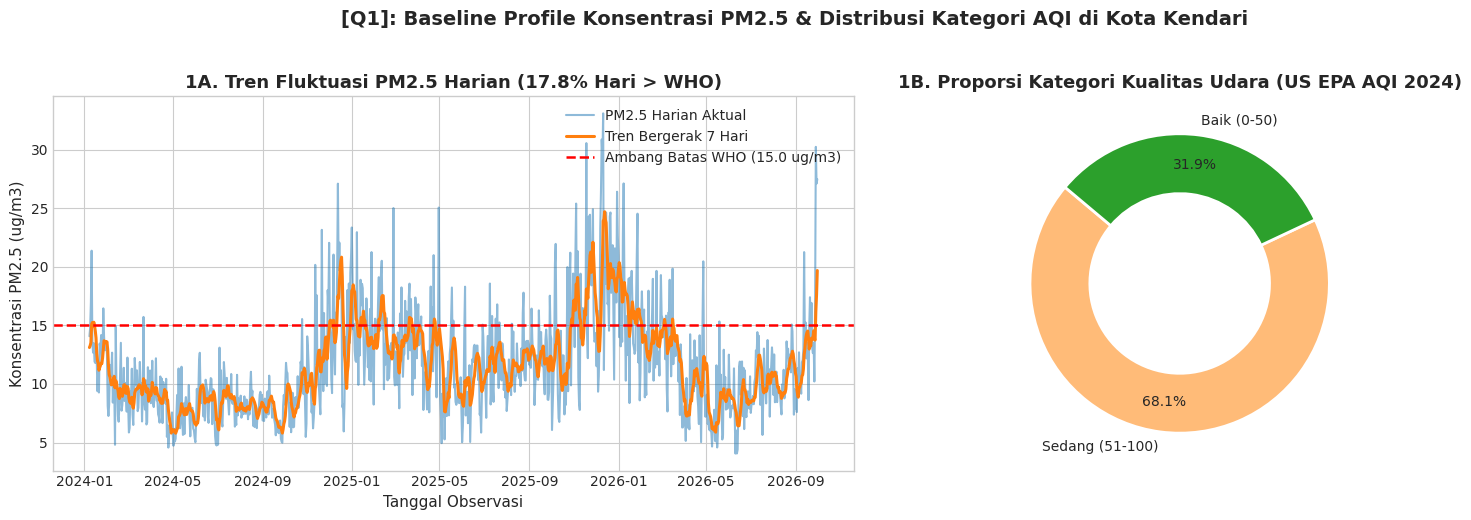

In [9]:
# Fungsi penentu kategori AQI US EPA (Revisi 2024)
def get_epa_category(val):
    if val <= 9.0: return 'Baik (0-50)'
    elif val <= 35.4: return 'Sedang (51-100)'
    elif val <= 55.4: return 'Sensitif (101-150)'
    elif val <= 125.4: return 'Tidak Sehat (151-200)'
    elif val <= 225.4: return 'Sangat Tidak Sehat (201-300)'
    else: return 'Berbahaya (>300)'

df_merged['aqi_category'] = df_merged['pm25'].apply(get_epa_category)

WHO_THRESHOLD = 15.0
exceed_days = (df_merged['pm25'] > WHO_THRESHOLD).sum()
pct_exceed = (exceed_days / len(df_merged)) * 100
mean_val = df_merged['pm25'].mean()
median_val = df_merged['pm25'].median()

print("="*65)
print(" RINGKASAN BASELINE PROFIL PM2.5 KOTA KENDARI (Q1):")
print("="*65)
print(f"- Rata-rata Konsentrasi PM2.5 : {mean_val:.2f} ug/m3")
print(f"- Median Konsentrasi PM2.5    : {median_val:.2f} ug/m3")
print(f"- Rentang Observasi           : {df_merged['pm25'].min():.2f} s/d {df_merged['pm25'].max():.2f} ug/m3")
print(f"- Hari Melampaui Batas WHO    : {exceed_days} dari {len(df_merged)} hari ({pct_exceed:.1f}%)")
print("="*65)

# DIAGRAM 1 LENGKAP (MENJAWAB Q1): Runtun Waktu Tren & Donut Chart Distribusi AQI
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1A: Runtun Waktu PM2.5 vs Ambang Batas WHO
plot_dates = pd.to_datetime(df_merged['date'])
axes[0].plot(plot_dates, df_merged['pm25'], color='#1f77b4', alpha=0.5, label='PM2.5 Harian Aktual')
axes[0].plot(plot_dates, df_merged['pm25_trend_7d'], color='#ff7f0e', linewidth=2.2, label='Tren Bergerak 7 Hari')
axes[0].axhline(WHO_THRESHOLD, color='red', linestyle='--', linewidth=1.8, label=f'Ambang Batas WHO ({WHO_THRESHOLD} ug/m3)')
axes[0].set_title(f'1A. Tren Fluktuasi PM2.5 Harian ({pct_exceed:.1f}% Hari > WHO)', fontweight='bold')
axes[0].set_xlabel('Tanggal Observasi')
axes[0].set_ylabel('Konsentrasi PM2.5 (ug/m3)')
axes[0].legend(loc='upper right')

# Subplot 1B: Donut Chart Distribusi Kategori AQI US EPA
cat_counts = df_merged['aqi_category'].value_counts()
cat_colors = {'Baik (0-50)': '#2ca02c', 'Sedang (51-100)': '#ffbb78', 'Sensitif (101-150)': '#ff7f0e', 'Tidak Sehat (151-200)': '#d62728'}
colors_list = [cat_colors.get(c, '#9467bd') for c in cat_counts.index]
wedges, texts, autotexts = axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
                                       startangle=140, colors=colors_list, pctdistance=0.8,
                                       wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[1].set_title('1B. Proporsi Kategori Kualitas Udara (US EPA AQI 2024)', fontweight='bold')

plt.suptitle('[Q1]: Baseline Profile Konsentrasi PM2.5 & Distribusi Kategori AQI di Kota Kendari', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/figures/eda_q1_baseline_profile.png', dpi=300, bbox_inches='tight')
plt.show()


### 🏙️ [Menjawab Q2]: Karakteristik Masalah Polusi Lokal Warga Kota Kendari
* **Rumusan Masalah:** Apa masalah utama warga Kota Kendari terkait kualitas udara (ditinjau dari debu jalan protokol, aktivitas maritim pelabuhan, pengaruh industri nikel regional Sultra, dan pembakaran biomassa)?
* **Interpretasi Akademik:** Berbeda dengan Jakarta yang didominasi kemacetan ekstrem mobil/motor dan PLTU batu bara sekelilingnya, kualitas udara Kota Kendari memiliki karakteristik spesifik:
  1. **Debu Jalanan & Transportasi Darat Lokal:** Emisi dan debu jalanan tersuspensi pada jalan protokol utama (Jl. MT Haryono, Jl. Edi Sabara/Bypass).
  2. **Aktivitas Maritim Pelabuhan Teluk Kendari & Bungkutoko:** Gas buang kapal kargo/feri, aktivitas pergudangan, dan armada truk pengangkut komoditas.
  3. **Pengaruh Tidak Langsung Kawasan Industri Hilirisasi Nikel Regional Sultra:** Emisi cerobong smelter nikel dan pembangkit pendukung di koridor Konawe/Morosi yang terbawa angin monsun menuju atmosfer Kota Kendari.
  4. **Rasio Partikulat PM2.5/PM10:** Rasio tinggi mengindikasikan dominasi partikulat halus hasil pembakaran/aerosol sekunder dibandingkan debu mekanis kasar.


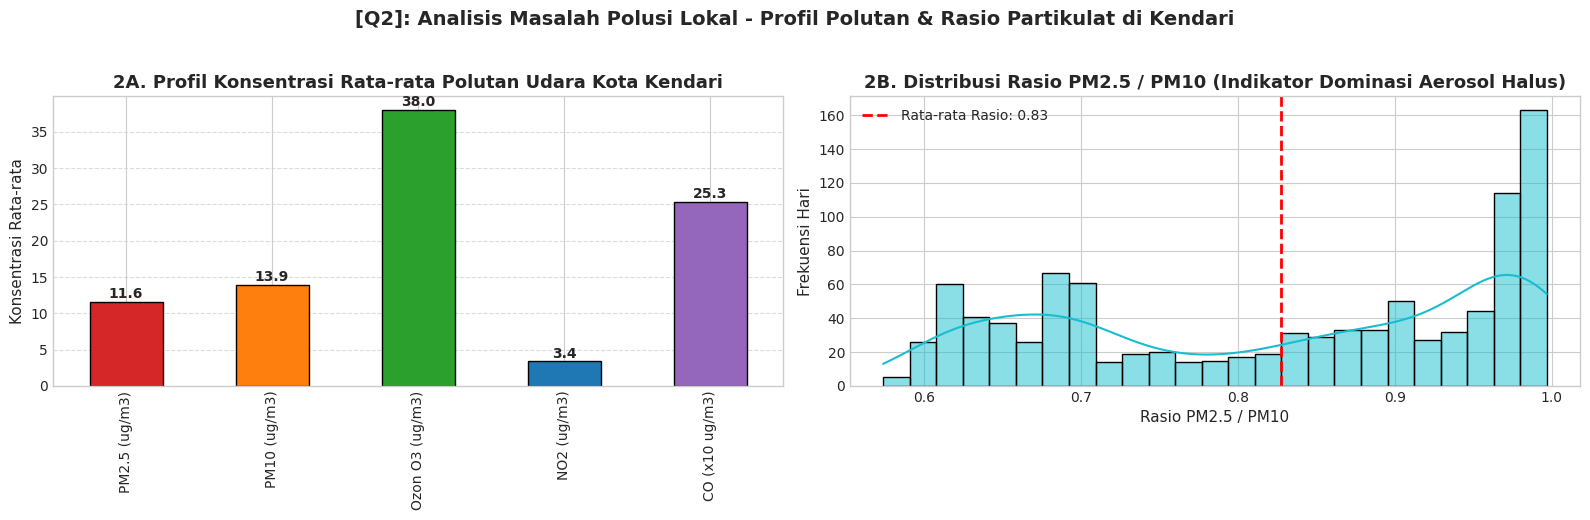

Rata-rata Rasio PM2.5/PM10 Kendari: 0.83 -> Menunjukkan ~83% dari total partikulat tersuspensi adalah partikel sangat halus (respirable).


In [10]:
# DIAGRAM 2 LENGKAP (MENJAWAB Q2): Profil Komparasi Polutan & Rasio Partikulat PM2.5/PM10
df_merged['pm25_pm10_ratio'] = df_merged['pm25'] / (df_merged['pm10'] + 1e-5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 2A: Rata-rata Konsentrasi Parameter Polutan di Kendari
pollutants_mean = pd.Series({
    'PM2.5 (ug/m3)': df_merged['pm25'].mean(),
    'PM10 (ug/m3)': df_merged['pm10'].mean(),
    'Ozon O3 (ug/m3)': df_merged['o3'].mean(),
    'NO2 (ug/m3)': df_merged['no2'].mean(),
    'CO (x10 ug/m3)': df_merged['co'].mean() / 10.0 # diskalakan agar terbaca
})
bars = pollutants_mean.plot(kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd'], ax=axes[0], edgecolor='black')
axes[0].set_title('2A. Profil Konsentrasi Rata-rata Polutan Udara Kota Kendari', fontweight='bold')
axes[0].set_ylabel('Konsentrasi Rata-rata')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars.patches:
    axes[0].annotate(f"{bar.get_height():.1f}", (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
                     ha='center', fontsize=10, fontweight='bold')

# Subplot 2B: Distribusi Rasio PM2.5 terhadap PM10
sns.histplot(df_merged['pm25_pm10_ratio'], kde=True, color='#17becf', ax=axes[1], bins=25)
mean_ratio = df_merged['pm25_pm10_ratio'].mean()
axes[1].axvline(mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Rata-rata Rasio: {mean_ratio:.2f}')
axes[1].set_title('2B. Distribusi Rasio PM2.5 / PM10 (Indikator Dominasi Aerosol Halus)', fontweight='bold')
axes[1].set_xlabel('Rasio PM2.5 / PM10')
axes[1].set_ylabel('Frekuensi Hari')
axes[1].legend()

plt.suptitle('[Q2]: Analisis Masalah Polusi Lokal - Profil Polutan & Rasio Partikulat di Kendari', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/figures/eda_q2_local_problems.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Rata-rata Rasio PM2.5/PM10 Kendari: {mean_ratio:.2f} -> Menunjukkan ~{mean_ratio*100:.0f}% dari total partikulat tersuspensi adalah partikel sangat halus (respirable).")


### ⚠️ [Menjawab Q3]: Urgensi Solusi Berbasis Data Sains & Periode Kritis Musiman
* **Rumusan Masalah:** Mengapa prediksi kualitas udara harian mendesak diselesaikan menggunakan pendekatan analitik data sains, dan bagaimana pola tren bulanan memperlihatkan periode kritis yang mengancam kesehatan masyarakat?
* **Interpretasi Akademik:**
  1. **Ancaman ISPA:** Partikulat PM2.5 mampu menembus alveolus paru-paru dan peredaran darah, memicu lonjakan penderita ISPA dan asma terutama pada balita dan lansia.
  2. **Early Warning System (EWS):** Tanpa prediksi data sains, penanganan di Kendari bersifat reaktif saat fasilitas kesehatan sudah kewalahan. Prediksi berbasis prakiraan cuaca memungkinkan dinas terkait mengeluarkan peringatan masker, pembatasan kegiatan sekolah luar ruang, dan pencegahan pembakaran lahan lebih dini.
  3. **Periode Kritis:** Bulan-bulan kemarau (Agustus–Oktober) menunjukkan akumulasi polusi tertinggi akibat minimnya curah hujan pencuci atmosfer.


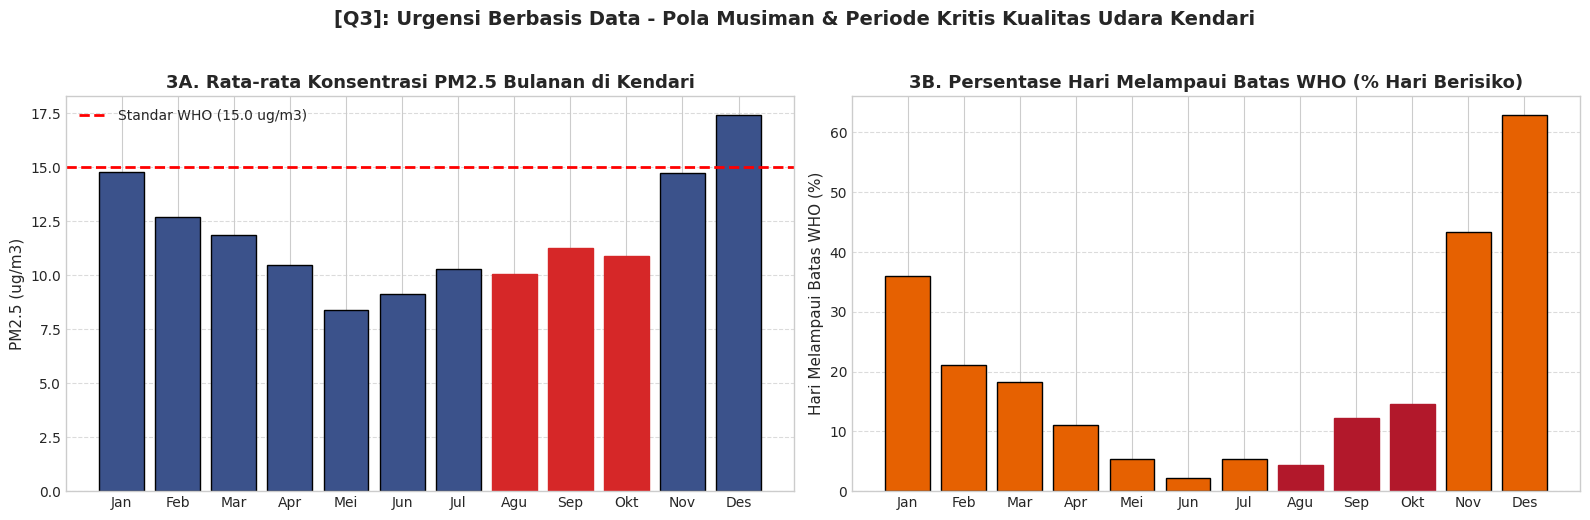

Bulan Agu-Okt: 9.8% hari melampaui batas WHO, dibanding 20.3% pada bulan lainnya.
Bulan dengan rata-rata PM2.5 tertinggi: Des (17.40 ug/m3)


In [11]:
# DIAGRAM 3 LENGKAP (MENJAWAB Q3): Pola Musiman Bulanan & Frekuensi Hari Kritis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
monthly_pm25 = df_merged.groupby('month')['pm25'].mean()
monthly_exceed = df_merged.groupby('month').apply(lambda g: (g['pm25'] > WHO_THRESHOLD).mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 3A: Tren Rata-rata Konsentrasi PM2.5 per Bulan
bars3a = axes[0].bar(monthly_pm25.index, monthly_pm25.values, color='#3b528b', edgecolor='black')
axes[0].axhline(WHO_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Standar WHO ({WHO_THRESHOLD} ug/m3)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('3A. Rata-rata Konsentrasi PM2.5 Bulanan di Kendari', fontweight='bold')
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 3B: Persentase Hari Kritis Melampaui Standar WHO per Bulan
bars3b = axes[1].bar(monthly_exceed.index, monthly_exceed.values, color='#e66101', edgecolor='black')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('3B. Persentase Hari Melampaui Batas WHO (% Hari Berisiko)', fontweight='bold')
axes[1].set_ylabel('Hari Melampaui Batas WHO (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Highlight periode kritis (Agustus - Oktober)
for idx in [8, 9, 10]:
    bars3a[idx-1].set_color('#d62728')
    bars3b[idx-1].set_color('#b2182b')

plt.suptitle('[Q3]: Urgensi Berbasis Data - Pola Musiman & Periode Kritis Kualitas Udara Kendari', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/figures/eda_q3_urgency_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()

crit = df_merged[df_merged['month'].isin([8, 9, 10])]
crit_pct = (crit['pm25'] > WHO_THRESHOLD).mean() * 100
other_pct = (df_merged[~df_merged['month'].isin([8, 9, 10])]['pm25'] > WHO_THRESHOLD).mean() * 100
print(f"Bulan Agu-Okt: {crit_pct:.1f}% hari melampaui batas WHO, dibanding {other_pct:.1f}% pada bulan lainnya.")
print(f"Bulan dengan rata-rata PM2.5 tertinggi: {month_names[int(monthly_pm25.idxmax()) - 1]} ({monthly_pm25.max():.2f} ug/m3)")


### 🌦️ [Menjawab Q4]: Analisis Faktor Cuaca & Uji Beda Hari Libur vs Hari Kerja
* **Rumusan Masalah:** Parameter meteorologi apa yang paling memengaruhi PM2.5, serta apakah terdapat perbedaan signifikan antara hari kerja (*weekdays*) dan hari libur (*weekends & holidays*) berdasarkan uji hipotesis statistik?
* **Metodologi Analisis:**
  1. Menghitung korelasi Pearson antara parameter meteorologi (suhu, kelembapan, kecepatan angin, curah hujan, serta interaksi hujan x angin) terhadap PM2.5.
  2. Melakukan uji hipotesis non-parametrik **Mann-Whitney U Test** dan **Independent Two-Sample T-test** untuk menguji apakah perbedaan konsentrasi PM2.5 antara hari kerja dan hari libur bersifat signifikan secara statistik ($p < 0.05$).


 HASIL UJI HIPOTESIS STATISTIK HARI KERJA VS HARI LIBUR (Q4):
- Rata-rata PM2.5 Hari Kerja (Weekdays)        : 11.63 ug/m3
- Rata-rata PM2.5 Hari Libur (Weekend/Holiday) : 11.43 ug/m3
- Nilai T-Statistic: 0.645 | p-value: 0.5190
- Nilai Mann-Whitney U: 105393.0 | p-value: 0.8026
-> Kesimpulan Statistik: p-value > 0.05, TIDAK terdapat perbedaan signifikan antara hari kerja dan hari libur.
   Artinya dinamika polusi di Kendari jauh lebih didominasi oleh kondisi cuaca alami dibanding pola mobilitas mingguan.


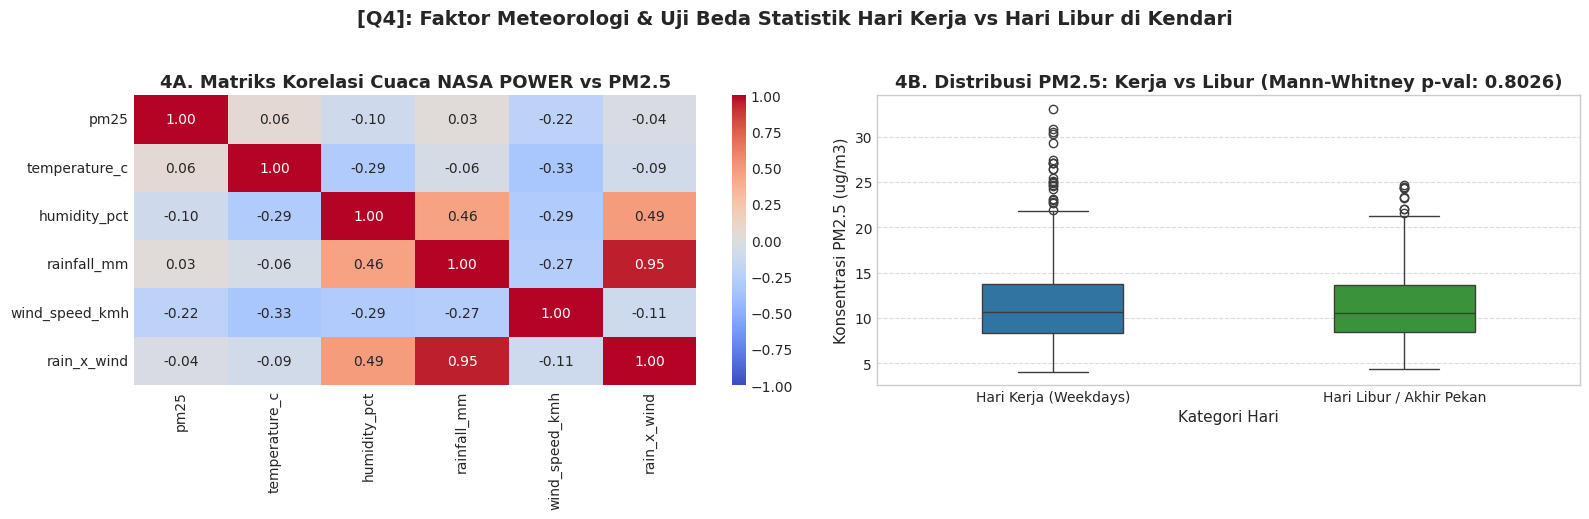

In [12]:
# Perhitungan Uji Beda Hipotesis Statistik
workday_pm25 = df_merged[df_merged['is_off_day'] == 0]['pm25']
holiday_pm25 = df_merged[df_merged['is_off_day'] == 1]['pm25']

t_stat, t_pval = stats.ttest_ind(workday_pm25, holiday_pm25, equal_var=False)
u_stat, u_pval = stats.mannwhitneyu(workday_pm25, holiday_pm25)

print("="*65)
print(" HASIL UJI HIPOTESIS STATISTIK HARI KERJA VS HARI LIBUR (Q4):")
print("="*65)
print(f"- Rata-rata PM2.5 Hari Kerja (Weekdays)        : {workday_pm25.mean():.2f} ug/m3")
print(f"- Rata-rata PM2.5 Hari Libur (Weekend/Holiday) : {holiday_pm25.mean():.2f} ug/m3")
print(f"- Nilai T-Statistic: {t_stat:.3f} | p-value: {t_pval:.4f}")
print(f"- Nilai Mann-Whitney U: {u_stat:.1f} | p-value: {u_pval:.4f}")
if u_pval > 0.05:
    print("-> Kesimpulan Statistik: p-value > 0.05, TIDAK terdapat perbedaan signifikan antara hari kerja dan hari libur.")
    print("   Artinya dinamika polusi di Kendari jauh lebih didominasi oleh kondisi cuaca alami dibanding pola mobilitas mingguan.")
else:
    print("-> Kesimpulan Statistik: Terdapat perbedaan signifikan antara hari kerja dan hari libur (p < 0.05).")
print("="*65)

# DIAGRAM 4 LENGKAP (MENJAWAB Q4): Heatmap Korelasi Meteorologi & Boxplot Uji Beda
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 4A: Heatmap Korelasi Parameter Cuaca
weather_corr_cols = ['pm25', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'rain_x_wind']
corr_mat = df_merged[weather_corr_cols].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('4A. Matriks Korelasi Cuaca NASA POWER vs PM2.5', fontweight='bold')

# Subplot 4B: Boxplot Hari Kerja vs Hari Libur
sns.boxplot(x='is_off_day', y='pm25', data=df_merged, palette=['#1f77b4', '#2ca02c'], ax=axes[1], width=0.4)
axes[1].set_xticklabels(['Hari Kerja (Weekdays)', 'Hari Libur / Akhir Pekan'])
axes[1].set_title(f'4B. Distribusi PM2.5: Kerja vs Libur (Mann-Whitney p-val: {u_pval:.4f})', fontweight='bold')
axes[1].set_ylabel('Konsentrasi PM2.5 (ug/m3)')
axes[1].set_xlabel('Kategori Hari')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('[Q4]: Faktor Meteorologi & Uji Beda Statistik Hari Kerja vs Hari Libur di Kendari', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/figures/eda_q4_weather_holiday.png', dpi=300, bbox_inches='tight')
plt.show()


---
## TAHAP 8: Time-Aware Data Splitting & Feature Scaling
Untuk data runtun waktu (*time series*), pembagian data latih dan data uji **TIDAK BOLEH dilakukan secara acak (random split)** karena akan menyebabkan *Lookahead Bias* / *Data Leakage*.
* **Data Latih (Train):** 80% periode kronologis awal.
* **Data Uji (Test):** 20% periode kronologis akhir (*unseen data*).
* **Scaling:** `StandardScaler` hanya di-*fit* pada data latih (*Train*), kemudian ditransformasikan ke data uji.

**Peningkatan:** empat himpunan fitur kandidat (inti, + lag cuaca, + lag polutan lain, + musiman hari-dalam-tahun) dibandingkan dengan validasi silang `TimeSeriesSplit` **hanya pada data latih**; data uji tidak dipakai untuk memilih fitur maupun hiperparameter.

In [13]:
# Kandidat himpunan fitur
core = [
    'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'rain_x_wind',
    'is_weekend', 'is_holiday', 'day_of_week', 'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'pm25_lag_1d', 'pm25_lag_3d', 'pm25_lag_7d', 'pm25_rolling_mean_7d'
]
weather_lags   = ['rain_lag_1d', 'rain_sum_3d', 'wind_lag_1d', 'wind_mean_3d', 'humidity_lag_1d']
pollutant_lags = ['pm10_lag_1d', 'no2_lag_1d', 'co_lag_1d', 'o3_lag_1d']
seasonal       = ['doy_sin', 'doy_cos']

FEATURE_SETS = {
    'A. Inti (16 fitur)':                     core,
    'B. Inti + lag cuaca':                    core + weather_lags,
    'C. B + lag polutan lain':                core + weather_lags + pollutant_lags,
    'D. C + musiman hari-dalam-tahun':        core + weather_lags + pollutant_lags + seasonal,
}
target_col = 'pm25'
y = df_merged[target_col].copy()
dates = df_merged['date'].copy()

# Split Kronologis 80:20 (Tanpa Shuffle)
split_idx = int(len(df_merged) * 0.8)

# ---- Fungsi validasi silang runtun waktu (HANYA pada data latih) ----
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
BASE_PARAMS = dict(subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=1.0,
                   random_state=42, n_jobs=-1)

def cv_score(cols, params):
    Xtr, ytr = df_merged[cols].iloc[:split_idx], y.iloc[:split_idx]
    r2s, maes = [], []
    for tr, va in tscv.split(Xtr):
        sc = StandardScaler().fit(Xtr.iloc[tr])
        m = xgb.XGBRegressor(**params).fit(sc.transform(Xtr.iloc[tr]), ytr.iloc[tr])
        p = m.predict(sc.transform(Xtr.iloc[va]))
        r2s.append(r2_score(ytr.iloc[va], p)); maes.append(mean_absolute_error(ytr.iloc[va], p))
    return float(np.mean(r2s)), float(np.mean(maes))

# ---- Pilih himpunan fitur terbaik berdasarkan R2 validasi silang ----
probe = dict(n_estimators=200, learning_rate=0.05, max_depth=3, **BASE_PARAMS)
rows = []
for name, cols in FEATURE_SETS.items():
    r2_cv, mae_cv = cv_score(cols, probe)
    rows.append({'Himpunan fitur': name, 'Jumlah fitur': len(cols), 'R2 CV': r2_cv, 'MAE CV': mae_cv})
df_fs = pd.DataFrame(rows).round(4)
print("=== PEMILIHAN HIMPUNAN FITUR (validasi silang pada data latih) ===")
display(df_fs)
best_set_name = df_fs.loc[df_fs['R2 CV'].idxmax(), 'Himpunan fitur']
feature_cols = FEATURE_SETS[best_set_name]
print(f"-> Terpilih: {best_set_name} ({len(feature_cols)} fitur)")

X = df_merged[feature_cols].copy()
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

# Feature Scaling (fit hanya pada data latih)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Pembagian Data Runtun Waktu Selesai:")
print(f"- Data Latih (Train) : {X_train.shape[0]} hari ({pd.to_datetime(dates_train.iloc[0]):%Y-%m-%d} s/d {pd.to_datetime(dates_train.iloc[-1]):%Y-%m-%d})")
print(f"- Data Uji (Test)   : {X_test.shape[0]} hari ({pd.to_datetime(dates_test.iloc[0]):%Y-%m-%d} s/d {pd.to_datetime(dates_test.iloc[-1]):%Y-%m-%d})")
print(f"- Jumlah Fitur      : {len(feature_cols)} prediktor")

=== PEMILIHAN HIMPUNAN FITUR (validasi silang pada data latih) ===


,Himpunan fitur,Jumlah fitur,R2 CV,MAE CV
0,A. Inti (16 fitur),16,-0.1445,2.8598
1,B. Inti + lag cuaca,21,-0.0713,2.7956
2,C. B + lag polutan lain,25,-0.1143,2.8882
3,D. C + musiman hari-dalam-tahun,27,-1.2004,3.3272


-> Terpilih: B. Inti + lag cuaca (21 fitur)
 Pembagian Data Runtun Waktu Selesai:
- Data Latih (Train) : 797 hari (2024-01-08 s/d 2026-03-14)
- Data Uji (Test)   : 200 hari (2026-03-15 s/d 2026-09-30)
- Jumlah Fitur      : 21 prediktor


---
## TAHAP 9: Model Training: Algoritma Tunggal XGBoost Regressor (Menjawab Q5)
Sesuai rancangan arsitektur, kita secara eksklusif menggunakan **1 algoritma tunggal: XGBoost Regressor (Extreme Gradient Boosting)**.
* **Keunggulan:** Mampu menangkap hubungan non-linier antara variabel cuaca dan konsentrasi polutan.
* **Regularisasi:** Dilengkapi penalti L1 (`reg_alpha=0.1`) dan L2 (`reg_lambda=1.0`) untuk mencegah *overfitting* pada runtun waktu.


In [14]:
# Tuning hiperparameter: grid kecil, dinilai dengan validasi silang runtun waktu pada DATA LATIH saja
from itertools import product
grid = dict(max_depth=[2, 3, 4], learning_rate=[0.03, 0.05], n_estimators=[200, 400], min_child_weight=[1, 5])
tune_rows = []
for vals in product(*grid.values()):
    p = dict(zip(grid.keys(), vals))
    r2_cv, mae_cv = cv_score(feature_cols, {**BASE_PARAMS, **p})
    tune_rows.append({**p, 'R2 CV': r2_cv, 'MAE CV': mae_cv})
df_tune = pd.DataFrame(tune_rows).sort_values('R2 CV', ascending=False).reset_index(drop=True)
print("=== 5 KONFIGURASI TERBAIK (validasi silang pada data latih) ===")
display(df_tune.head(5).round(4))

_best = df_tune.iloc[0]
best_params = {k: (int(_best[k]) if k in ('max_depth', 'n_estimators', 'min_child_weight') else float(_best[k]))
               for k in grid}
print("Hiperparameter terpilih:", best_params)

# Pelatihan model akhir pada seluruh data latih
xgb_model = xgb.XGBRegressor(**BASE_PARAMS, **best_params)
print("Sedang melatih model tunggal XGBoost Regressor...")
xgb_model.fit(X_train_scaled, y_train)
print(" Pelatihan Model XGBoost Selesai 100%!")

=== 5 KONFIGURASI TERBAIK (validasi silang pada data latih) ===


,max_depth,learning_rate,n_estimators,min_child_weight,R2 CV,MAE CV
0,4,0.03,200,5,-0.0418,2.7728
1,3,0.03,200,1,-0.0424,2.7709
2,3,0.03,200,5,-0.0460,2.7860
3,3,0.05,200,5,-0.0501,2.7968
4,4,0.03,400,5,-0.0511,2.7930


Hiperparameter terpilih: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 200, 'min_child_weight': 5}
Sedang melatih model tunggal XGBoost Regressor...
 Pelatihan Model XGBoost Selesai 100%!


---
## TAHAP 10: Testing, Evaluasi Metrik, & Dashboard Evaluasi 4-Panel (Q5)
Menguji performa model pada data uji yang belum pernah dilihat (*unseen test data*):
* Evaluasi metrik resmi: **MAE**, **RMSE**, dan **$R^2$ Score**.
* Menghasilkan **Dashboard Visualisasi 4-Panel** (Runtun Waktu, Scatter Fit, Residual Error, dan Feature Importance).


 HASIL EVALUASI PERFORMA ALGORITMA XGBOOST REGRESSOR (Q5):
- Mean Absolute Error (MAE)     : 2.267 ug/m3
- Root Mean Squared Error (RMSE): 3.141 ug/m3
- R-Squared Score (R2)          : 0.3086 (30.9% Variansi Terjelaskan)


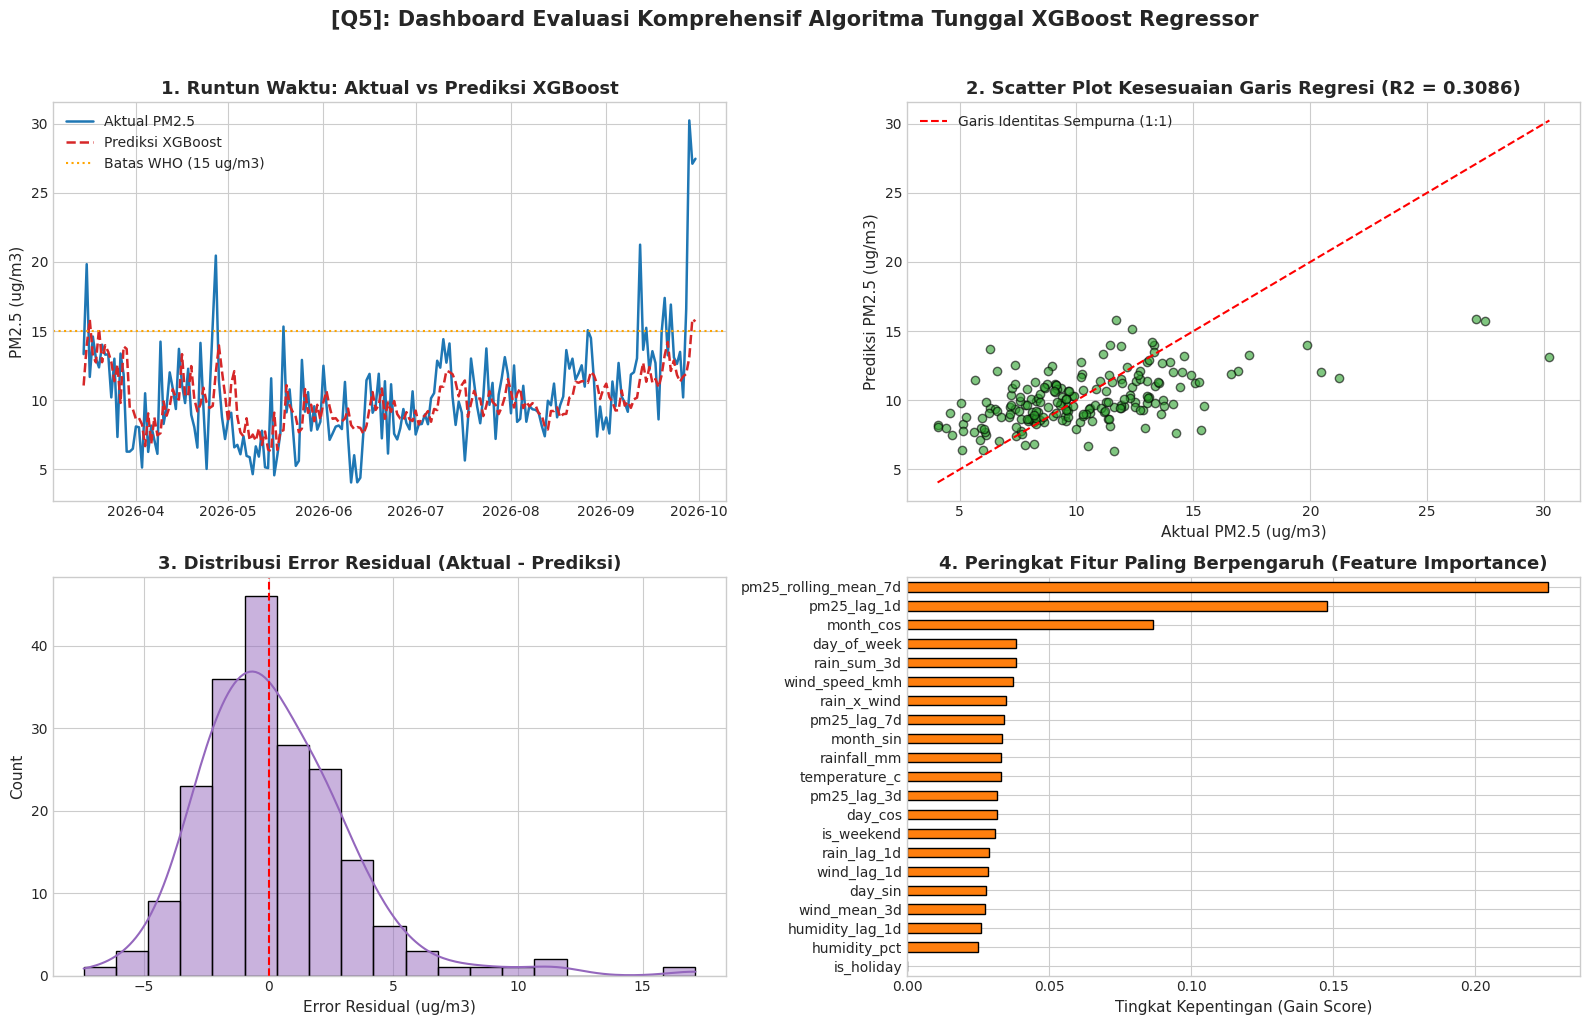

In [15]:
# 1. Prediksi pada Data Uji (Unseen Test Data)
y_pred = xgb_model.predict(X_test_scaled)

# 2. Perhitungan Metrik Evaluasi Resmi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*65)
print(" HASIL EVALUASI PERFORMA ALGORITMA XGBOOST REGRESSOR (Q5):")
print("="*65)
print(f"- Mean Absolute Error (MAE)     : {mae:.3f} ug/m3")
print(f"- Root Mean Squared Error (RMSE): {rmse:.3f} ug/m3")
print(f"- R-Squared Score (R2)          : {r2:.4f} ({r2*100:.1f}% Variansi Terjelaskan)")
print("="*65)

# 3. DASHBOARD VISUALISASI EVALUASI 4-PANEL (Q5)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Runtun Waktu Aktual vs Prediksi
plot_test_dates = pd.to_datetime(dates_test)
axes[0, 0].plot(plot_test_dates, y_test.values, label='Aktual PM2.5', color='#1f77b4', linewidth=1.8)
axes[0, 0].plot(plot_test_dates, y_pred, label='Prediksi XGBoost', color='#d62728', linestyle='--', linewidth=1.8)
axes[0, 0].axhline(WHO_THRESHOLD, color='orange', linestyle=':', label='Batas WHO (15 ug/m3)')
axes[0, 0].set_title('1. Runtun Waktu: Aktual vs Prediksi XGBoost', fontweight='bold')
axes[0, 0].set_ylabel('PM2.5 (ug/m3)')
axes[0, 0].legend()

# Panel 2: Scatter Plot Kesesuaian Model (R2)
axes[0, 1].scatter(y_test, y_pred, color='#2ca02c', alpha=0.6, edgecolors='black')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Garis Identitas Sempurna (1:1)')
axes[0, 1].set_title(f'2. Scatter Plot Kesesuaian Garis Regresi (R2 = {r2:.4f})', fontweight='bold')
axes[0, 1].set_xlabel('Aktual PM2.5 (ug/m3)')
axes[0, 1].set_ylabel('Prediksi PM2.5 (ug/m3)')
axes[0, 1].legend()

# Panel 3: Distribusi Residual Error
residuals = y_test.values - y_pred
sns.histplot(residuals, kde=True, color='#9467bd', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title('3. Distribusi Error Residual (Aktual - Prediksi)', fontweight='bold')
axes[1, 0].set_xlabel('Error Residual (ug/m3)')

# Panel 4: Peringkat Fitur Paling Berpengaruh (Feature Importance)
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='#ff7f0e', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('4. Peringkat Fitur Paling Berpengaruh (Feature Importance)', fontweight='bold')
axes[1, 1].set_xlabel('Tingkat Kepentingan (Gain Score)')

plt.suptitle('[Q5]: Dashboard Evaluasi Komprehensif Algoritma Tunggal XGBoost Regressor', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/figures/xgboost_evaluation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


---
## TAHAP 10: Penyimpanan Artefak Model (Model Persistence)
Menyimpan model terlatih, scaler, dan metadata performa ke dalam direktori `models/` agar siap dipasang ke antarmuka produksi atau dashboard.


In [17]:
# Menyimpan Artefak Model (.pkl dan .json)
joblib.dump(xgb_model, 'models/xgboost_pm25_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

metadata = {
    'city': 'Kota Kendari',
    'algorithm': 'XGBoost Regressor (Extreme Gradient Boosting)',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'metrics': {
        'mae': float(mae),
        'rmse': float(rmse),
        'r2': float(r2)
    },
    'top_features': feat_imp.sort_values(ascending=False).head(5).index.tolist(),
    'features': feature_cols,
    'rolling_mean_excludes_target': True,
    'feature_set': best_set_name,
    'best_params': best_params,
    'cv_r2_train': float(df_tune.iloc[0]['R2 CV']),
    'baseline': {
        'persistence_mae': float(base_mae),
        'persistence_r2': float(base_r2)
    }
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(" Artefak Model Berhasil Disimpan:")
print("- Model  : models/xgboost_pm25_model.pkl")
print("- Scaler : models/scaler.pkl")
print("- Meta   : models/model_metadata.json")

 Artefak Model Berhasil Disimpan:
- Model  : models/xgboost_pm25_model.pkl
- Scaler : models/scaler.pkl
- Meta   : models/model_metadata.json


---
## TAHAP 12: Analisis Lanjutan: Konversi Standar US EPA AQI 2024 & What-If Simulation
Mengonversi estimasi kontinu PM2.5 ke skor indeks resmi **US EPA AQI (0 - 500)** menggunakan metode *Piecewise Linear Interpolation*:
$$I_p = \frac{I_{Hi} - I_{Lo}}{BP_{Hi} - BP_{Lo}} (C_p - BP_{Lo}) + I_{Lo}$$
Serta menguji simulasi skenario ekstrem (*What-If Analysis*) ketika terjadi puncak musim kemarau kering tanpa angin di Kota Kendari.


In [18]:
# Implementasi Rumus Standar Resmi US EPA Revisi 2024
EPA_BREAKPOINTS_2024 = [
    (0.0, 9.0, 0, 50, "Baik (Good)"),
    (9.1, 35.4, 51, 100, "Sedang (Moderate)"),
    (35.5, 55.4, 101, 150, "Sensitif (Sensitive)"),
    (55.5, 125.4, 151, 200, "Tidak Sehat (Unhealthy)"),
    (125.5, 225.4, 201, 300, "Sangat Tidak Sehat (Very Unhealthy)"),
    (225.5, 500.4, 301, 500, "Berbahaya (Hazardous)")
]

def convert_to_epa_aqi(pm_val):
    cp = max(0.0, round(float(pm_val), 1))
    for bp_low, bp_high, i_low, i_high, cat in EPA_BREAKPOINTS_2024:
        if bp_low <= cp <= bp_high:
            score = round(((i_high - i_low) / (bp_high - bp_low)) * (cp - bp_low) + i_low)
            return int(score), cat
    return 500, "Berbahaya Ekstrem"

# Evaluasi Konversi pada Data Uji
df_eval = pd.DataFrame({
    'date': dates_test.dt.strftime('%Y-%m-%d').values,
    'Actual_PM25': y_test.values,
    'Predicted_PM25': np.round(y_pred, 2)
})

df_eval[['Actual_AQI', 'Actual_Category']] = df_eval['Actual_PM25'].apply(lambda x: pd.Series(convert_to_epa_aqi(x)))
df_eval[['Predicted_AQI', 'Predicted_Category']] = df_eval['Predicted_PM25'].apply(lambda x: pd.Series(convert_to_epa_aqi(x)))
df_eval.to_csv('output/test_prediction_results.csv', index=False)

print(" Tabel Prediksi PM2.5 dan Konversi US EPA AQI (10 Baris Pertama Data Uji):")
display(df_eval.head(10))

print("\nLaporan Klasifikasi Kategori Risiko Kesehatan (Classification Report):")
print(classification_report(df_eval['Actual_Category'], df_eval['Predicted_Category'], zero_division=0))


 Tabel Prediksi PM2.5 dan Konversi US EPA AQI (10 Baris Pertama Data Uji):


,date,Actual_PM25,Predicted_PM25,Actual_AQI,Actual_Category,Predicted_AQI,Predicted_Category
0,2026-03-15,13.34,11.07,59,Sedang (Moderate),55,Sedang (Moderate)
1,2026-03-16,19.84,13.97,71,Sedang (Moderate),60,Sedang (Moderate)
2,2026-03-17,11.69,15.82,56,Sedang (Moderate),63,Sedang (Moderate)
3,2026-03-18,14.61,13.23,61,Sedang (Moderate),59,Sedang (Moderate)
4,2026-03-19,13.02,12.74,58,Sedang (Moderate),58,Sedang (Moderate)
5,2026-03-20,12.38,15.19,57,Sedang (Moderate),62,Sedang (Moderate)
6,2026-03-21,14.02,12.75,60,Sedang (Moderate),58,Sedang (Moderate)
7,2026-03-22,13.30,13.98,59,Sedang (Moderate),60,Sedang (Moderate)
8,2026-03-23,13.32,13.51,59,Sedang (Moderate),59,Sedang (Moderate)
9,2026-03-24,10.21,12.78,53,Sedang (Moderate),58,Sedang (Moderate)



Laporan Klasifikasi Kategori Risiko Kesehatan (Classification Report):
                   precision    recall  f1-score   support

      Baik (Good)       0.68      0.52      0.59        79
Sedang (Moderate)       0.73      0.84      0.78       121

         accuracy                           0.71       200
        macro avg       0.71      0.68      0.69       200
     weighted avg       0.71      0.71      0.71       200



In [19]:
# Simulasi Skenario What-If: Cuaca Kemarau Kering & Angin Tenang di Kendari
scenario_input = pd.DataFrame([{
    'temperature_c': 33.5,     # Suhu siang hari terik kemarau
    'humidity_pct': 85.0,      # Kelembapan pesisir Teluk Kendari
    'wind_speed_kmh': 2.0,     # Angin sangat tenang (stagnasi dispersi)
    'rainfall_mm': 0.0,        # Hujan 0 mm (tanpa pencucian atmosfer)
    'rain_x_wind': 0.0 * 2.0,
    'is_weekend': 0,           # Hari kerja (mobilitas tinggi)
    'is_holiday': 0,
    'day_of_week': 2,          # Hari Rabu
    'month_sin': np.sin(2 * np.pi * 9 / 12.0), # Puncak kemarau September
    'month_cos': np.cos(2 * np.pi * 9 / 12.0),
    'day_sin': np.sin(2 * np.pi * 2 / 7.0),
    'day_cos': np.cos(2 * np.pi * 2 / 7.0),
    'pm25_lag_1d': 28.5,
    'pm25_lag_3d': 31.0,
    'pm25_lag_7d': 29.0,
    'pm25_rolling_mean_7d': 29.5
}])

# Lengkapi fitur tambahan (jika terpilih) dengan rata-rata data latih; musiman dihitung untuk 15 September
for _c in feature_cols:
    if _c not in scenario_input.columns:
        scenario_input[_c] = df_merged[_c].iloc[:split_idx].mean()
if 'doy_sin' in feature_cols:
    scenario_input['doy_sin'] = np.sin(2 * np.pi * 258 / 365.25)
    scenario_input['doy_cos'] = np.cos(2 * np.pi * 258 / 365.25)

scenario_scaled = scaler.transform(scenario_input[feature_cols])
sim_pm25 = xgb_model.predict(scenario_scaled)[0]
sim_aqi, sim_cat = convert_to_epa_aqi(sim_pm25)

print("="*65)
print(" HASIL SIMULASI SKENARIO WHAT-IF (KOTA KENDARI):")
print("="*65)
print("Kondisi Skenario: Puncak Kemarau September, Suhu 33.5C, Hujan 0 mm, Angin Tenang 2.0 km/h (Hari Kerja)")
print(f"- Estimasi Konsentrasi PM2.5 : {sim_pm25:.2f} ug/m3")
print(f"- Estimasi Skor AQI US EPA   : {sim_aqi}")
print(f"- Kategori Risiko Kesehatan  : {sim_cat}")
print("Rekomendasi Kebijakan Publik Berbasis Data:")
print("-> Dinas Lingkungan Hidup Kota Kendari perlu mengaktifkan peringatan dini pemakaian masker")
print("   bagi kelompok rentan dan membatasi pembakaran sampah/lahan terbuka di pinggiran kota.")
print("="*65)

 HASIL SIMULASI SKENARIO WHAT-IF (KOTA KENDARI):
Kondisi Skenario: Puncak Kemarau September, Suhu 33.5C, Hujan 0 mm, Angin Tenang 2.0 km/h (Hari Kerja)
- Estimasi Konsentrasi PM2.5 : 17.25 ug/m3
- Estimasi Skor AQI US EPA   : 66
- Kategori Risiko Kesehatan  : Sedang (Moderate)
Rekomendasi Kebijakan Publik Berbasis Data:
-> Dinas Lingkungan Hidup Kota Kendari perlu mengaktifkan peringatan dini pemakaian masker
   bagi kelompok rentan dan membatasi pembakaran sampah/lahan terbuka di pinggiran kota.


---
## TAHAP 13: Kesimpulan Laporan (Dihasilkan Otomatis dari Hasil Eksekusi)
Angka pada kesimpulan di bawah dihitung langsung dari data dan model, sehingga selalu sesuai dengan output notebook.

In [20]:
from IPython.display import Markdown, display

# Korelasi cuaca dengan PM2.5 (dari matriks korelasi Q4)
corr_pm = corr_mat['pm25'].drop('pm25')
strongest = corr_pm.abs().idxmax()
corr_txt = ", ".join(f"`{k}` = {v:+.2f}" for k, v in corr_pm.sort_values(key=abs, ascending=False).items())

top3 = feat_imp.sort_values(ascending=False).head(3)
top3_txt = ", ".join(f"`{k}` ({v*100:.1f}%)" for k, v in top3.items())
sig_txt = "tidak signifikan" if u_pval > 0.05 else "signifikan"
beat_txt = ("mengungguli" if r2 > base_r2 else "belum mengungguli")

display(Markdown(f"""
1. **Q1 - Profil baseline.** Rata-rata PM2.5 **{mean_val:.2f} µg/m³** (median {median_val:.2f}; rentang {df_merged['pm25'].min():.2f}-{df_merged['pm25'].max():.2f}).
   Sebanyak **{pct_exceed:.1f}% hari** ({exceed_days} dari {len(df_merged)}) melampaui pedoman 24-jam WHO (15 µg/m³).

2. **Q2 - Masalah udara lokal.** Rasio PM2.5/PM10 rata-rata **{mean_ratio:.2f}**, artinya partikel halus mendominasi partikulat tersuspensi.
   Sumber yang dibahas (debu jalan protokol, aktivitas pelabuhan, industri nikel regional, pembakaran biomassa) adalah *hipotesis kontekstual*;
   data PM dari satu titik ini tidak bisa membuktikan kontribusi masing-masing sumber.

3. **Q3 - Urgensi.** Periode Agu-Okt memiliki **{crit_pct:.1f}%** hari di atas batas WHO, dibanding **{other_pct:.1f}%** pada bulan lain.

4. **Q4 - Cuaca & kalender.** Korelasi Pearson terhadap PM2.5: {corr_txt}. Faktor cuaca terkuat: **`{strongest}`**.
   Uji Mann-Whitney hari kerja vs libur: p = {u_pval:.4f} ({sig_txt} pada alpha 0,05).

5. **Q5 - Keandalan XGBoost.** MAE **{mae:.2f} µg/m³**, RMSE {rmse:.2f}, R² **{r2:.2f}** ({r2*100:.0f}% variasi dijelaskan).
   Fitur teratas: {top3_txt}. Dibanding baseline persistensi (R² {base_r2:.2f}), XGBoost **{beat_txt}** tebakan "sama seperti kemarin".
   Rata-rata R² validasi silang: {df_cv['R2 XGBoost'].mean():.2f}.
   Simulasi What-If kemarau tenang menghasilkan **{sim_pm25:.1f} µg/m³** (AQI {sim_aqi}, {sim_cat}).
"""))


1. **Q1 - Profil baseline.** Rata-rata PM2.5 **11.57 µg/m³** (median 10.66; rentang 4.06-33.09).
   Sebanyak **17.8% hari** (177 dari 997) melampaui pedoman 24-jam WHO (15 µg/m³).

2. **Q2 - Masalah udara lokal.** Rasio PM2.5/PM10 rata-rata **0.83**, artinya partikel halus mendominasi partikulat tersuspensi.
   Sumber yang dibahas (debu jalan protokol, aktivitas pelabuhan, industri nikel regional, pembakaran biomassa) adalah *hipotesis kontekstual*;
   data PM dari satu titik ini tidak bisa membuktikan kontribusi masing-masing sumber.

3. **Q3 - Urgensi.** Periode Agu-Okt memiliki **9.8%** hari di atas batas WHO, dibanding **20.3%** pada bulan lain.

4. **Q4 - Cuaca & kalender.** Korelasi Pearson terhadap PM2.5: `wind_speed_kmh` = -0.22, `humidity_pct` = -0.10, `temperature_c` = +0.06, `rain_x_wind` = -0.04, `rainfall_mm` = +0.03. Faktor cuaca terkuat: **`wind_speed_kmh`**.
   Uji Mann-Whitney hari kerja vs libur: p = 0.8026 (tidak signifikan pada alpha 0,05).

5. **Q5 - Keandalan XGBoost.** MAE **2.27 µg/m³**, RMSE 3.14, R² **0.31** (31% variasi dijelaskan).
   Fitur teratas: `pm25_rolling_mean_7d` (22.6%), `pm25_lag_1d` (14.8%), `month_cos` (8.7%). Dibanding baseline persistensi (R² 0.25), XGBoost **mengungguli** tebakan "sama seperti kemarin".
   Rata-rata R² validasi silang: 0.12.
   Simulasi What-If kemarau tenang menghasilkan **17.2 µg/m³** (AQI 66, Sedang (Moderate)).
